Import Libraries



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

Load data

In [46]:
df=pd.read_csv('StudentsPerformance.csv')

In [47]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [48]:
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [49]:
df.shape

(1000, 8)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [51]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Target Feature

In [52]:
df["FinalScore"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
) / 3


In [53]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,FinalScore
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


Encoding

In [54]:
df["gender"].unique()


array(['female', 'male'], dtype=object)

In [55]:
df["gender"] = df["gender"].map({
    "male": 0,
    "female": 1
})


In [56]:
df["race/ethnicity"].unique()

array(['group B', 'group C', 'group A', 'group D', 'group E'],
      dtype=object)

In [57]:
df = pd.get_dummies(df, columns=["race/ethnicity"], drop_first=True)


In [58]:
df["parental level of education"].unique()

array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'],
      dtype=object)

In [59]:
education_map = {
    'some high school':0,
    "high school": 1,
    "some college": 2,
    "associate's degree": 3,
    "bachelor's degree": 4,
    "master's degree": 5
}

df["parental level of education"] = df["parental level of education"].map(education_map)


In [60]:
df["lunch"].unique()

array(['standard', 'free/reduced'], dtype=object)

In [61]:
df["lunch"] = df["lunch"].map({
    "free/reduced": 0,
    "standard": 1
})


In [62]:
df["test preparation course"].unique()

array(['none', 'completed'], dtype=object)

In [63]:
df["test preparation course"] = df["test preparation course"].map({
    "none": 0,
    "completed": 1
})


In [64]:
df.columns

Index(['gender', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'FinalScore', 'race/ethnicity_group B',
       'race/ethnicity_group C', 'race/ethnicity_group D',
       'race/ethnicity_group E'],
      dtype='object')

Correlation Matrix

<Axes: >

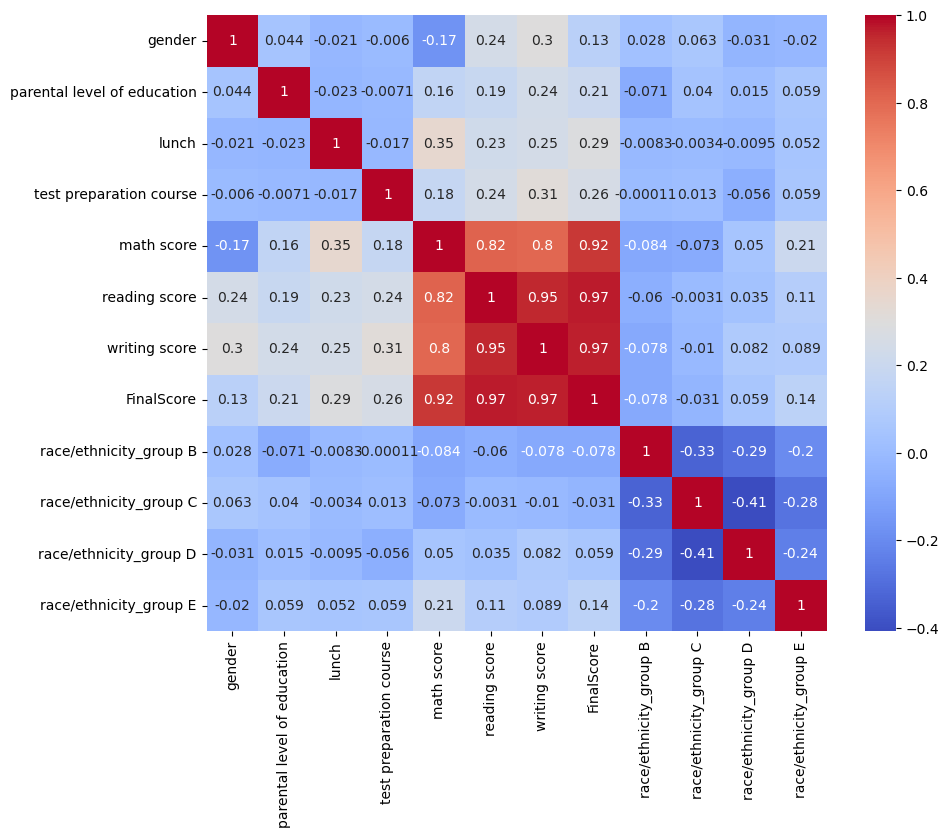

In [65]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

Split

In [66]:
X = df.drop(columns=["FinalScore","reading score","writing score"])
y = df["FinalScore"]


In [67]:
print(X.dtypes)


gender                         int64
parental level of education    int64
lunch                          int64
test preparation course        int64
math score                     int64
race/ethnicity_group B          bool
race/ethnicity_group C          bool
race/ethnicity_group D          bool
race/ethnicity_group E          bool
dtype: object


Normalization

In [68]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Train test split

In [69]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

Model training

In [70]:

# Train
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Prediction

In [71]:
y_pred = model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print results
print("Model Performance")
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Model Performance
MSE: 11.340859744625595
RMSE: 3.3676192992417646
R2 Score: 0.9470959491446245


Coefficients

In [72]:
coeff_df = pd.DataFrame(
    model.coef_,
    index=X.columns,
    columns=["Coefficient"]
)
coeff_df["Abs_Coefficient"] = abs(coeff_df["Coefficient"])

print("Feature Importance:")
print(coeff_df)


Feature Importance:
                             Coefficient  Abs_Coefficient
gender                          4.115299         4.115299
parental level of education     0.528201         0.528201
lunch                          -0.621391         0.621391
test preparation course         1.226898         1.226898
math score                     13.799401        13.799401
race/ethnicity_group B         -0.139329         0.139329
race/ethnicity_group C          0.137130         0.137130
race/ethnicity_group D          0.193764         0.193764
race/ethnicity_group E         -0.820342         0.820342


Coefficient Visualization

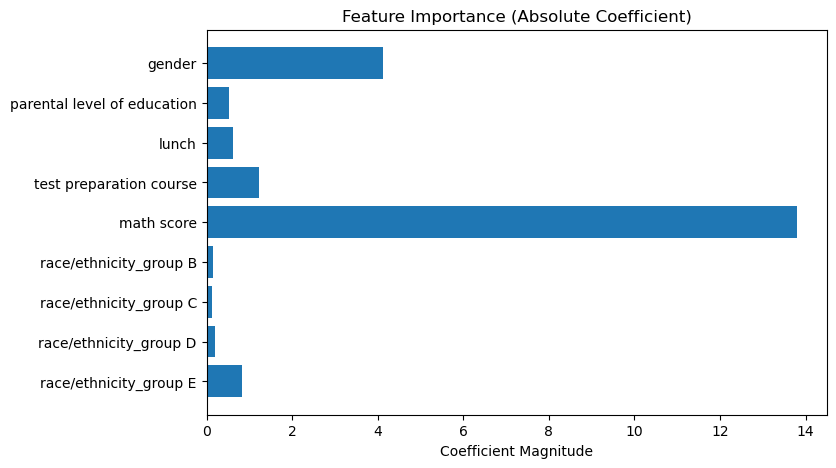

In [73]:
plt.figure(figsize=(8,5))
plt.barh(coeff_df.index, coeff_df["Abs_Coefficient"])
plt.xlabel("Coefficient Magnitude")
plt.title("Feature Importance (Absolute Coefficient)")
plt.gca().invert_yaxis()
plt.show()


Predicted vs Actual Plot

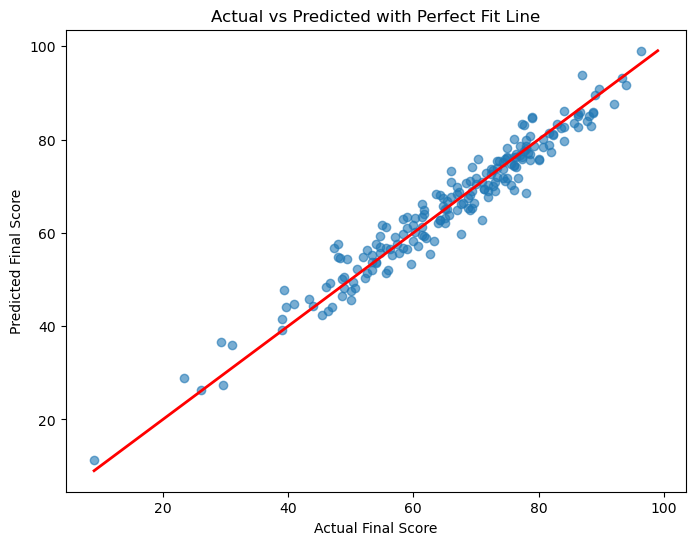

In [74]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val],
         [min_val, max_val],
         color='red', linewidth=2)

plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Actual vs Predicted with Perfect Fit Line")
plt.show()


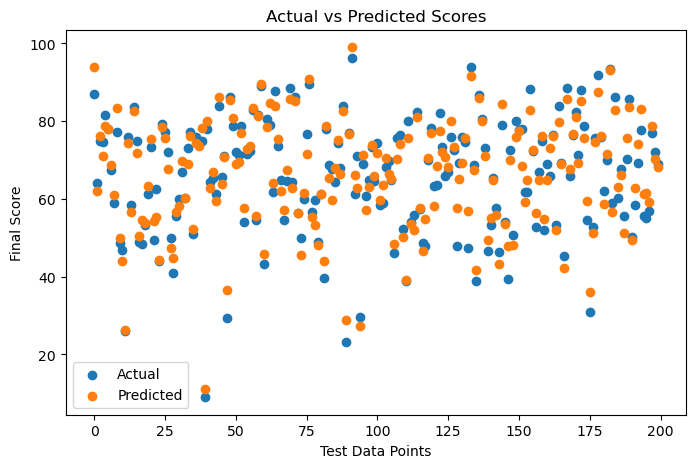

In [75]:
y_pred = model.predict(X_test)

plt.figure(figsize=(8,5))

plt.scatter(range(len(y_test)), y_test, label="Actual")
plt.scatter(range(len(y_pred)), y_pred, label="Predicted")

plt.xlabel("Test Data Points")
plt.ylabel("Final Score")
plt.title("Actual vs Predicted Scores")
plt.legend()

plt.show()

Residual Distribution Plot

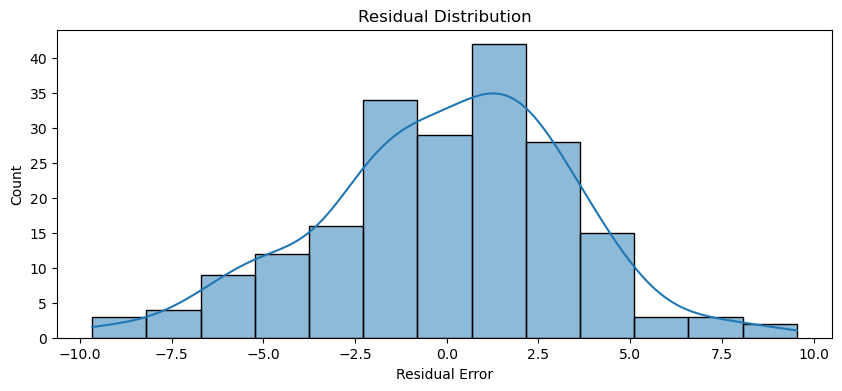

In [76]:
residuals = y_test - y_pred

plt.figure(figsize=(10,4))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual Error")
plt.show()


Ridge Regression

In [77]:
ridge = Ridge(alpha=0.9)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

print("\nRidge Regression Performance")
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("R2:", r2_score(y_test, y_pred_ridge))



Ridge Regression Performance
MSE: 11.344691360959608
RMSE: 3.368188142155899
R2: 0.9470780750125076


Lasso Regression

In [78]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

print("\nLasso Regression Performance")
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("R2:", r2_score(y_test, y_pred_lasso))



Lasso Regression Performance
MSE: 11.342764365682267
RMSE: 3.367902071866441
R2: 0.9470870642653902


Compare All Models

In [79]:
comparison = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso"],
    "R2 Score": [
        r2_score(y_test, y_pred),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso)
    ]
})

comparison


,Model,R2 Score
0,Linear,0.947096
1,Ridge,0.947078
2,Lasso,0.947087
